# Generic Tuning Interface

## Motivation

So far, the tutorials have focused on parameter sweeps along predefined dimensions. While these sweeps do not need to be linear, all parameter values must still be known in advance before compiling the QUA program.

However, many practical optimization problems require **adaptive and non-linear exploration** of parameter space, where future values depend on previous measurement results.

Quantum Machines hardware provides a solution via *input streams*, which allow parameters to be updated dynamically during program execution. (See the [official documentation](https://docs.quantum-machines.co/latest/docs/Guides/features/#input-streams) for more details.)

The `GenericTuningInterface` in Arbok builds on this feature to enable adaptive tuning workflows with minimal changes to existing measurement definitions.

In this tutorial, we demonstrate a real-world example: optimizing the initialization and readout of two different spin parity states. The underlying physics is not essential here—the focus is on how the interface enables flexible and scalable optimization.

## The `GenericTuningInterface`

### Creating the driver and a measurement

As in previous tutorials, we begin by creating a `Device` and initializing the corresponding driver. The device configuration defines the hardware setup, while the driver provides the interface to the Quantum Machines backend.

In [1]:
from arbok_driver import ArbokDriver, Device, Measurement
from arbok_driver.examples.configurations import opx1000_config
from arbok_driver.examples.configurations import (
    device_config, parity_init_conf, parity_read_conf
)

mock_device = Device(
    name = 'mock_device',
    opx_config = opx1000_config,
    divider_config = {},
    master_config = device_config
)

qm_driver = ArbokDriver('qm_driver', mock_device)

2026-03-23 08:26:34,924 - qm - INFO     - Starting session: f77a903a-305e-438f-984d-089a7a43fa72


Next, we construct a measurement consisting of four subsequences:
- initialization (even parity)
- readout (even parity)
- initialization (odd parity)
- readout (odd parity)

At this stage, the even and odd branches are identical apart from their naming. The goal of the optimization will be to maximize the distinguishability between these two cases.

In [2]:
mock_measurement = Measurement(qm_driver, 'mock_measurement')

mock_measurement.add_subsequences_from_dict({
    'paraity_init_even': {'config': parity_init_conf},
    'parity_read_even': {'config': parity_read_conf},
    'parity_init_odd': {'config': parity_init_conf},
    'parity_read_odd': {'config': parity_read_conf}
})

### Initializing the interface

To construct the tuning interface, three components must be defined:

1. **Cost strategy**  
   A `CostStrategy` implementation that evaluates the quality of each measurement result. It has access to all relevant gettables and returns a scalar cost value. In this example, we use a placeholder implementation returning random values.

2. **Parameter configuration**  
   A dictionary describing which parameters should be tuned. Each entry maps a high-level tuning parameter to one or more underlying QUA variables, along with scaling factors and bounds.

3. **Sweeps**  
   Sweep definitions determine the structure of the acquired data (e.g., averaging). These are equivalent to standard measurement sweeps.

In [3]:
from arbok_driver.generic_tunig_interface import CostStrategy

import numpy as np

class CustomStrategy(CostStrategy):
    def get_cost(self, results: dict) -> float:
        return float(np.random.normal(loc = 0.5))
    
parity_cost_strat = CustomStrategy(
    gettables = mock_measurement.available_gettables,
    )

If you are not sure which gettables are available you can always inspect the available gettables:

In [4]:
#[g.full_name for g in mock_measurement.available_gettables]

The parameter dictionary defines how high-level tuning parameters map to underlying QUA variables.

Each entry consists of:
- `qua_vars`: a mapping from QUA parameters to scaling factors  
- `bounds`: the allowed range for the parameter during optimization  

This allows multiple physical parameters to be controlled simultaneously through a single tuning variable. For example, the `read_detuning` parameter modifies both readout branches in a coordinated way, including sign inversion where required.

To inspect available parameters, use:

In [5]:
#mock_measurement.print_readable_snapshot()

In [6]:
tuning_interface = mock_measurement.initialize_tuning_interface(
    parameter_dicts = {
        't_ramp_init': {
            'qua_vars': {mock_measurement.parity_init_odd.arbok_params.t_ramp_over_crossing: 1},
            'bounds': (25, 1e4)
            },
        'read_detuning': {
            'qua_vars': {
                mock_measurement.parity_read_even.arbok_params.v_read['P1']: 1,
                mock_measurement.parity_read_even.arbok_params.v_read['P2']: -1,
                mock_measurement.parity_read_odd.arbok_params.v_read['P1']: 1,
                mock_measurement.parity_read_odd.arbok_params.v_read['P2']: -1,
                },
            'bounds': (-0.01, 0.01)
            },
        },
    cost_strategy = parity_cost_strat,
    sweeps = [{mock_measurement.iteration: np.arange(100)}],
    verbose = True
)

Adding input stream for t_ramp_over_crossing (t_ramp_init)

Adding input stream for v_read_P1 (read_detuning)

Adding v_read_P2 to v_read_P1  input stream (factor: -1) (read_detuning)

Adding v_read_P1 to v_read_P1  input stream (factor: 1) (read_detuning)

Adding v_read_P2 to v_read_P1  input stream (factor: -1) (read_detuning)

Declared 1-dimensional parameter sweep of size 100 [100]
Registered 16 gettables for measurement


The resulting QUA program differs from a standard measurement in that selected parameters are replaced by variables connected to input streams. This enables values to be updated dynamically at runtime without recompilation.

In [7]:
mock_measurement.print_qua_program_to_file('parity_program_with_input_streams.py')

The interface is now ready for execution. In this tutorial, we operate in mock mode, but the same workflow applies to real hardware.

Parameter sets can be evaluated using `run_parameter_set`, which:
- streams the provided values into the program
- executes the measurement
- returns the computed cost and recorded data

In [8]:
qm_driver.is_mock = True
mock_measurement.mock_steps = 0
# mock_measurement.tuning_interface.compile_connect_and_run( host_ip = 'xxx.xxx.xxx.xxx')

### The first steps

The tuning interface is now ready to be used. Values to be measured can now be inserted the following way via `run_parameter_set`:

In [9]:
step_dict = {
        mock_measurement.parity_init_odd.arbok_params.t_ramp_over_crossing: 100,
        mock_measurement.parity_read_even.arbok_params.v_read['P1']: 0.1
    }
cost, gettable_results, saved_params = tuning_interface.run_parameter_set(step_dict)

## Cross-entropy sampling

Exploring high-dimensional parameter spaces manually is often impractical. To address this, the interface includes a cross-entropy sampling algorithm for automated optimization.

The method operates iteratively:
1. Generate a population of random parameter sets within the defined bounds.
2. Evaluate their performance using the cost function.
3. Select the top-performing fraction (`select_frac`).
4. Shrink the parameter bounds based on these elite samples.
5. Repeat for subsequent populations.

This approach efficiently concentrates the search around promising regions of parameter space while maintaining robustness against local minima.

<Figure size 640x480 with 0 Axes>

Total time elapsed: 2s

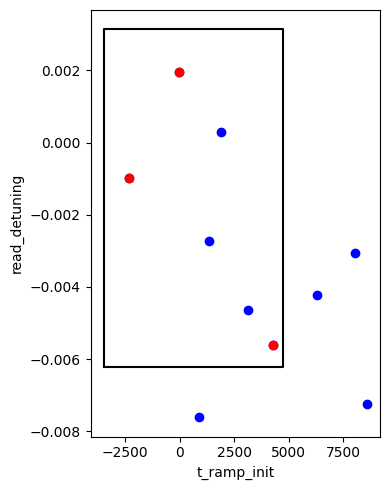

<xarray.Dataset> Size: 514kB
Dimensions:                       (index: 40, shot_nr: 100)
Coordinates:
  * index                         (index) int64 320B 0 1 2 3 4 ... 36 37 38 39
  * shot_nr                       (shot_nr) int64 800B 0 1 2 3 4 ... 96 97 98 99
Data variables: (12/19)
    rewards                       (index) float64 320B -0.08109 ... 1.077
    parity_read_even_ref__p1p2    (index, shot_nr) float64 32kB 0.0 ... 1.0
    parity_read_even_ref__p7p8    (index, shot_nr) float64 32kB 0.0 ... 1.0
    parity_read_even_read__p1p2   (index, shot_nr) float64 32kB 0.0 ... 1.0
    parity_read_even_read__p7p8   (index, shot_nr) float64 32kB 0.0 ... 1.0
    parity_read_even_diff__p1p2   (index, shot_nr) float64 32kB 0.0 ... 1.0
    ...                            ...
    parity_read_odd_diff__p1p2    (index, shot_nr) float64 32kB 0.0 ... 1.0
    parity_read_odd_diff__p7p8    (index, shot_nr) float64 32kB 0.0 ... 1.0
    parity_read_odd_state__p1p2   (index, shot_nr) float64 32kB 0.0 ... 1.0
    parity_read_odd_state__p7p8   (index, shot_nr) float64 32kB 0.0 ... 1.0
    t_ramp_init                   (index) float64 320B 440.5 2.59e+03 ... 881.8
    read_detuning                 (index) float64 320B -0.0043 ... -0.007606
Attributes:
    parameters:   ['t_ramp_init', 'read_detuning']
    populations:  [20, 10, 10]
    bounds:       (-0.009857086934846429, 0.0022476051332392124)

In [11]:
dataset = tuning_interface.run_cross_entropy_sampler(
    populations = [20, 10, 10],
    select_frac = 0.25,
    plot_histograms = True,
    sampling_params_to_plot = [('t_ramp_init', 'read_detuning')]
)
dataset

## Summary

In this tutorial, we introduced the `GenericTuningInterface`, a flexible framework for adaptive parameter optimization in quantum experiments.

By leveraging input streams, the interface enables dynamic parameter updates during execution, removing the need for predefined sweeps. This allows efficient exploration of high-dimensional and non-linear parameter spaces.

We demonstrated how to:
- define a custom cost function via `CostStrategy`,
- map high-level tuning parameters to underlying QUA variables,
- execute parameter updates in real time,
- and perform automated optimization using cross-entropy sampling.

The interface provides a scalable and extensible approach to experiment tuning, combining hardware-efficient execution with flexible software abstractions. It is particularly well suited for complex experiments where performance depends on many interdependent parameters.